# Session 3 - Data Preprocessing
## From Raw Scraped Data to an Analytical Dataset

This notebook is part of the *Head of Data 101* end-to-end project.

Role of this notebook:
- Input: raw scraped data stored in `data/raw/`
- Output: cleaned and structured dataset stored in `data/processed/`
- Purpose: transform imperfect real-world data into a defensible analytical dataset

Design principles:
- Raw data is never modified
- Preprocessing decisions must be explicit and justifiable
- The notebook is intentionally simple and modular
- This is not modeling or optimization
- This notebook is a baseline example to be adapted by students

---


## 1. Loading the raw dataset

We start by loading the raw dataset exactly as it was collected during the scraping phase.

Important:
- Raw data must not be modified or overwritten
- All preprocessing outputs will be saved separately
- We assume the file is located in `data/raw/`

The raw file format is consistent across runs and should contain these columns:
- make, model, mileage, price, registration, fuel, country, brand, page

---


In [1]:
# Import the main libraries we will use in this notebook
import pandas as pd  # Work with tabular data (tables)
import numpy as np  # Work with numeric operations and arrays
from pathlib import Path  # Work with file paths in a clean way
from datetime import datetime  # Create timestamps for output files
import matplotlib.pyplot as plt  # Plot charts for data visualization
from IPython.display import display  # Show multiple tables in one cell


In [2]:
# Find the repository root (the folder that contains the data/ directory)
# This makes the notebook work even if you run it from a subfolder
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'data').exists():
    # Move one folder up until we find data/
    repo_root = repo_root.parent

# Point to the raw data folder and list available files
raw_dir = repo_root / 'data' / 'raw'
raw_files = sorted(raw_dir.glob('*.csv'))
raw_files  # Display the available raw files


[WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head of Data 101/Github repo/HeadOfData101/data/raw/autoscout24_listings_20251221_121306.csv'),
 WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head of Data 101/Github repo/HeadOfData101/data/raw/autoscout24_listings_20251221_122247.csv'),
 WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head of Data 101/Github repo/HeadOfData101/data/raw/autoscout24_listings_20251221_140155.csv'),
 WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head of Data 101/Github repo/HeadOfData101/data/raw/autoscout24_listings_20251221_142336.csv'),
 WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head of Data 101/Github repo/HeadOfData101/data/raw/autoscout24_listings_audi_a3_germany_20251227_175315.csv'),
 WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head o

In [3]:
# Pick the most recent Audi A3 Germany raw file automatically
pattern = 'autoscout24_listings_audi_a3_germany_*.csv'
raw_files = sorted(raw_dir.glob(pattern))
if not raw_files:
    raise FileNotFoundError(f'No raw files found matching {pattern} in {raw_dir}')
raw_path = raw_files[-1]  # Latest by filename timestamp
print('Using raw file:', raw_path.name)

# Load the raw data without changes
df_raw = pd.read_csv(raw_path)
df_raw.head()  # Show the first rows


Using raw file: autoscout24_listings_audi_a3_germany_20251227_230815.csv


,make,model,mileage,price,price_label,registration,fuel,country,power_hp,country_name,page
0,audi,a3,234163,690,toolow-price,06-2003,d,d,105.0,germany,1
1,audi,a3,76000,16980,good-price,12-2014,b,d,179.0,germany,1
2,audi,a3,174549,9950,top-price,04-2015,d,d,110.0,germany,1
3,audi,a3,91700,13950,top-price,12-2013,b,d,179.0,germany,1
4,audi,a3,36216,22950,top-price,12-2022,b,d,150.0,germany,1


In [4]:
# Create a working copy for preprocessing (raw data stays unchanged)
df = df_raw.copy()

# Ensure brand exists for downstream steps (single-make scrape)
if 'brand' not in df.columns:
    df['brand'] = df['make']


In [5]:
# Check that the raw file has the expected format (fixed schema)
expected_columns_default = [
    'make', 'model', 'mileage', 'price', 'registration', 'fuel', 'country', 'brand', 'page'
]
expected_columns_audi = [
    'make', 'model', 'mileage', 'price', 'price_label', 'registration', 'fuel', 'country', 'power_hp', 'country_name', 'page'
]

# If the column list is different, stop and fix the input file first
if list(df_raw.columns) not in [expected_columns_default, expected_columns_audi]:
    raise ValueError(
        f'Unexpected columns. Expected: {expected_columns_default} or {expected_columns_audi} | Found: {list(df_raw.columns)}'
    )
else:
    print('Column names are as expected.')


Column names are as expected.


## 2. Initial data inspection

Before cleaning anything, we must understand what kind of data we are working with.

At this stage we:
- Inspect column names
- Check data types
- Look at sample rows
- Quantify missing values

No cleaning decisions are taken yet.

---


In [6]:
# Check the size of the dataset (rows, columns)
df_raw.shape


(3999, 11)

In [7]:
# List the column names to confirm what we have
df_raw.columns


Index(['make', 'model', 'mileage', 'price', 'price_label', 'registration',
       'fuel', 'country', 'power_hp', 'country_name', 'page'],
      dtype='object')

In [8]:
# Show the data type of each column
# Notice that many columns may be objects (strings) even if they look numeric
df_raw.dtypes


make             object
model            object
mileage          object
price             int64
price_label      object
registration     object
fuel             object
country          object
power_hp        float64
country_name     object
page              int64
dtype: object

In [9]:
# Show a sample of rows to get a feel for the data
df_raw.head(10)


,make,model,mileage,price,price_label,registration,fuel,country,power_hp,country_name,page
0,audi,a3,234163,690,toolow-price,06-2003,d,d,105.0,germany,1
1,audi,a3,76000,16980,good-price,12-2014,b,d,179.0,germany,1
2,audi,a3,174549,9950,top-price,04-2015,d,d,110.0,germany,1
3,audi,a3,91700,13950,top-price,12-2013,b,d,179.0,germany,1
4,audi,a3,36216,22950,top-price,12-2022,b,d,150.0,germany,1
5,audi,a3,86100,15990,top-price,02-2017,b,d,150.0,germany,1
6,audi,a3,210000,6980,good-price,04-2015,b,d,125.0,germany,1
7,audi,a3,37816,22990,top-price,10-2021,b,d,150.0,germany,1
8,audi,a3,18900,34900,unknown,12-2024,b,d,150.0,germany,1
9,audi,a3,14712,23630,good-price,11-2022,2,d,150.0,germany,1


## 3. Understanding missing values

Missing values are common in scraped data and do not all mean the same thing.

In this section we:
- Identify which columns contain missing values
- Measure the proportion of missing values per column
- Discuss what missing values may represent in this dataset

At this stage, we only observe and document.

---


In [10]:
# Count missing values per column
missing_count = df_raw.isna().sum()

# Convert to percent to compare columns with different sizes
missing_percent = (missing_count / len(df_raw)) * 100

# Create a small summary table for easy reading
missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent.round(2),
}).sort_values('missing_percent', ascending=False)

missing_summary


,missing_count,missing_percent
power_hp,1,0.03
model,0,0.00
make,0,0.00
mileage,0,0.00
price,0,0.00
registration,0,0.00
price_label,0,0.00
fuel,0,0.00
country,0,0.00
country_name,0,0.00


**Optional decision: remove rows with missing values**

Run the next cell only if the class agrees to drop rows with missing data.
Otherwise, keep them and handle missing values in a different way (e.g., imputation).


In [11]:
# OPTIONAL DECISION: drop rows with missing values
# Run this cell only if the class agrees that missing values should be removed
# You can also specify a subset of columns, for example: df = df.dropna(subset=['price', 'mileage'])
df = df.dropna()
df.shape


(3998, 12)

## 4. Data type correction and basic formatting

Many columns are not stored using the correct data types.

Typical issues include:
- Numeric values stored as strings
- Dates stored as text
- Mixed formats within the same column

In this section we:
- Convert columns to appropriate data types
- Standardize date formats
- Ensure numeric columns are truly numeric

These transformations are necessary for any downstream analysis.

---


In [12]:
# Work on a copy to keep raw data unchanged
# Convert numeric columns (errors become NaN instead of crashing)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
df['power_hp'] = pd.to_numeric(df['power_hp'], errors='coerce')
# Keep the original registration text so we can inspect it later
df['registration_raw'] = df['registration']
# Convert registration to a real date (expected format: MM-YYYY)
df['registration_date'] = pd.to_datetime(df['registration'], format='%m-%Y', errors='coerce')
# Extract year and month for easier analysis
df['registration_year'] = df['registration_date'].dt.year
df['registration_month'] = df['registration_date'].dt.month
# Show a few converted rows as a quick check
df[['price', 'mileage', 'registration_date']].head()


,price,mileage,registration_date
0,690,234163.0,2003-06-01
1,16980,76000.0,2014-12-01
2,9950,174549.0,2015-04-01
3,13950,91700.0,2013-12-01
4,22950,36216.0,2022-12-01


## 5. Normalizing categorical variables

Some categorical variables appear as codes or inconsistent labels.

Examples:
- Country codes instead of country names
- Engine or fuel types encoded numerically
- Inconsistent capitalization or spelling

In this section we:
- Inspect categorical value distributions
- Map coded values to human-readable categories
- Standardize category labels

The goal is clarity and consistency, not perfect taxonomy.

---


In [13]:
# Standardize text columns to lowercase and remove extra spaces
df['make'] = df['make'].astype('string').str.strip().str.lower()
df['model'] = df['model'].astype('string').str.strip().str.lower()
df['brand'] = df['brand'].astype('string').str.strip().str.lower()
df['fuel'] = df['fuel'].astype('string').str.strip().str.lower()
df['price_label'] = df['price_label'].astype('string').str.strip().str.lower()
df['country'] = df['country'].astype('string').str.strip().str.lower()

# Map fuel codes to readable labels (extend if new codes appear)
fuel_mapping = {
    'd': 'diesel',
    'b': 'petrol',
    'e': 'electric',
    'l': 'lpg',
    'h': 'hybrid',
}
df['fuel_clean'] = df['fuel'].map(fuel_mapping).fillna(df['fuel'])

# Map country codes to readable names (partial list for teaching)
country_mapping = {
    'd': 'germany',
    'b': 'belgium',
    'i': 'italy',
    'f': 'france',
    'nl': 'netherlands',
    'e': 'spain',
}
df['country_clean'] = df['country'].map(country_mapping).fillna(df['country'])

# Compare original vs cleaned values
df[['fuel', 'fuel_clean', 'country', 'country_clean']].head()


,fuel,fuel_clean,country,country_clean
0,d,diesel,d,germany
1,b,petrol,d,germany
2,d,diesel,d,germany
3,b,petrol,d,germany
4,b,petrol,d,germany


## 6. Detecting duplicated records

Scraped data often contains duplicated or near-duplicated records.

In this section we:
- Check for exact duplicate rows
- Explore which columns could define uniqueness
- Discuss whether rows represent unique cars or unique listings

A decision is made and clearly documented.

---


In [14]:
# Count exact duplicates across all columns
duplicate_count = df.duplicated().sum()
duplicate_count


np.int64(1)

**Optional decision: remove exact duplicate rows**

Run the next cell only if the class agrees duplicates should be removed.
If duplicates represent repeated listings, you may prefer to keep them.


In [15]:
# OPTIONAL DECISION: remove exact duplicate rows to keep one copy
# Run this cell only if the class agrees duplicates should be removed
df = df.drop_duplicates()
df.shape  # Check the new size


(3997, 18)

## 7. Outliers and extreme values

Extreme values may represent:
- Legitimate rare cases
- Data entry errors
- Scraping or parsing issues

In this section we:
- Identify outliers in key numerical variables
- Visualize distributions where helpful
- Decide how to handle extreme values (keep, cap, remove, or flag)

Outliers are not removed automatically.

---


In [16]:
# Function to flag outliers using the IQR (interquartile range) rule
def iqr_outlier_flags(series):
    # Compute the first and third quartiles
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    # The IQR is the spread between q3 and q1
    iqr = q3 - q1
    # Define lower and upper bounds for outliers
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    # Return True for values outside the bounds
    return (series < lower) | (series > upper)

# Create outlier flags for price and mileage
df['price_outlier_iqr'] = iqr_outlier_flags(df['price'])
df['mileage_outlier_iqr'] = iqr_outlier_flags(df['mileage'])
df['power_outlier_iqr'] = iqr_outlier_flags(df['power_hp'])

# Inspect a few rows to see the flags
df[['price', 'price_outlier_iqr', 'mileage', 'mileage_outlier_iqr', 'power_hp', 'power_outlier_iqr']].head()


,price,price_outlier_iqr,mileage,mileage_outlier_iqr,power_hp,power_outlier_iqr
0,690,False,234163.0,False,105.0,False
1,16980,False,76000.0,False,179.0,False
2,9950,False,174549.0,False,110.0,False
3,13950,False,91700.0,False,179.0,False
4,22950,False,36216.0,False,150.0,False


In [17]:
# Count how many price values are flagged as outliers
df['price_outlier_iqr'].value_counts(dropna=False)


price_outlier_iqr
False    3988
True        9
Name: count, dtype: int64

In [18]:
# Count how many mileage values are flagged as outliers
df['mileage_outlier_iqr'].value_counts(dropna=False)

# Count how many power values are flagged as outliers
df['power_outlier_iqr'].value_counts(dropna=False)


power_outlier_iqr
False    3499
True      498
Name: count, dtype: int64

**Optional decision: remove outliers**

Run the next cell only if the class agrees to remove outliers.
Outliers can be valid rare cases, so deletion is not automatic.


In [19]:
# OPTIONAL DECISION: drop rows flagged as outliers
# Run this cell only if the class agrees to remove outliers
# This uses the IQR flags we created above
df = df[~(df['price_outlier_iqr'] | df['mileage_outlier_iqr'] | df['power_outlier_iqr'])]
df.shape


(3421, 21)

In [20]:
# Inspect the 10 most extreme price values (highest and lowest)
# This helps us see if extreme values look plausible or suspicious
price_cols = [
    'make', 'model', 'price', 'mileage', 'registration_date', 'fuel_clean', 'country_clean', 'page'
]
price_cols = [col for col in price_cols if col in df.columns]

price_top10 = df.dropna(subset=['price']).nlargest(10, 'price')[price_cols]
price_bottom10 = df.dropna(subset=['price']).nsmallest(10, 'price')[price_cols]

print('Top 10 prices')
display(price_top10)
print('Bottom 10 prices')
display(price_bottom10)


Top 10 prices


,make,model,price,mileage,registration_date,fuel_clean,country_clean,page
3765,audi,a3,50790,15000.0,2025-03-01,diesel,germany,189
2063,audi,a3,49890,4444.0,2025-12-01,diesel,germany,104
3796,audi,a3,47150,1.0,NaT,petrol,germany,190
3047,audi,a3,46990,5500.0,2025-12-01,petrol,germany,153
3551,audi,a3,46930,3000.0,2025-10-01,petrol,germany,178
2664,audi,a3,45990,15.0,2025-12-01,2,germany,134
3711,audi,a3,45980,3090.0,2025-11-01,petrol,germany,186
3894,audi,a3,45950,0.0,NaT,petrol,germany,195
3636,audi,a3,45840,19990.0,2024-08-01,petrol,germany,182
2720,audi,a3,44890,16363.0,2024-11-01,diesel,germany,137


Bottom 10 prices


,make,model,price,mileage,registration_date,fuel_clean,country_clean,page
685,audi,a3,500,213000.0,2004-10-01,petrol,germany,35
740,audi,a3,500,160000.0,1997-01-01,petrol,germany,38
802,audi,a3,500,252000.0,1999-08-01,petrol,germany,41
944,audi,a3,500,180000.0,2000-01-01,petrol,unknown,48
680,audi,a3,590,245274.0,2004-07-01,petrol,germany,35
885,audi,a3,650,235000.0,2005-01-01,petrol,germany,45
0,audi,a3,690,234163.0,2003-06-01,diesel,germany,1
1358,audi,a3,900,237827.0,1998-01-01,petrol,germany,68
861,audi,a3,950,196350.0,2000-02-01,petrol,germany,44
1760,audi,a3,1000,206000.0,2000-12-01,petrol,unknown,89


In [21]:
# Inspect the 10 most extreme mileage values (highest and lowest)
# This helps us detect very large or very small mileage values
mileage_cols = [
    'make', 'model', 'price', 'mileage', 'registration_date', 'fuel_clean', 'country_clean', 'page'
]
mileage_cols = [col for col in mileage_cols if col in df.columns]

mileage_top10 = df.dropna(subset=['mileage']).nlargest(10, 'mileage')[mileage_cols]
mileage_bottom10 = df.dropna(subset=['mileage']).nsmallest(10, 'mileage')[mileage_cols]

print('Top 10 mileage values')
display(mileage_top10)
print('Bottom 10 mileage values')
display(mileage_bottom10)


Top 10 mileage values


,make,model,price,mileage,registration_date,fuel_clean,country_clean,page
1813,audi,a3,7200,265000.0,2012-12-01,diesel,germany,91
2496,audi,a3,5000,265000.0,2004-04-01,petrol,germany,125
811,audi,a3,1799,264000.0,2005-11-01,petrol,germany,41
1221,audi,a3,6800,263915.0,2011-04-01,diesel,germany,62
1392,audi,a3,1300,262852.0,2000-06-01,petrol,germany,70
1369,audi,a3,5900,262000.0,2012-05-01,diesel,germany,69
758,audi,a3,4999,261200.0,2008-08-01,diesel,germany,38
467,audi,a3,4500,260000.0,2012-10-01,petrol,germany,24
1053,audi,a3,2799,259999.0,2006-11-01,petrol,germany,53
684,audi,a3,2666,259500.0,2007-05-01,diesel,germany,35


Bottom 10 mileage values


,make,model,price,mileage,registration_date,fuel_clean,country_clean,page
254,audi,a3,40990,0.0,NaT,petrol,germany,13
299,audi,a3,24380,0.0,NaT,petrol,germany,16
2037,audi,a3,39990,0.0,NaT,petrol,germany,102
2279,audi,a3,29998,0.0,NaT,diesel,unknown,115
2727,audi,a3,39990,0.0,NaT,petrol,germany,137
2800,audi,a3,39990,0.0,NaT,petrol,germany,141
2818,audi,a3,36440,0.0,NaT,petrol,germany,141
3119,audi,a3,25280,0.0,NaT,petrol,germany,157
3199,audi,a3,26620,0.0,NaT,petrol,germany,161
3212,audi,a3,39940,0.0,NaT,petrol,germany,161


In [22]:
# Inspect the 10 most extreme power values (highest and lowest)
# This helps us detect very large or very small power values
power_cols = [
    'make', 'model', 'price', 'mileage', 'power_hp', 'registration_date', 'fuel_clean', 'country_clean', 'page'
]
power_cols = [col for col in power_cols if col in df.columns]

power_top10 = df.dropna(subset=['power_hp']).nlargest(10, 'power_hp')[power_cols]
power_bottom10 = df.dropna(subset=['power_hp']).nsmallest(10, 'power_hp')[power_cols]

print('Top 10 power values (hp)')
display(power_top10)
print('Bottom 10 power values (hp)')
display(power_bottom10)


Top 10 power values (hp)


,make,model,price,mileage,power_hp,registration_date,fuel_clean,country_clean,page
62,audi,a3,29480,55190.0,200.0,2022-04-01,diesel,germany,4
141,audi,a3,34749,78450.0,200.0,2023-05-01,diesel,germany,8
192,audi,a3,26480,95300.0,200.0,2022-05-01,diesel,germany,10
256,audi,a3,34880,24726.0,200.0,2023-04-01,diesel,germany,13
309,audi,a3,33890,84000.0,200.0,2023-03-01,diesel,germany,16
324,audi,a3,31888,97600.0,200.0,2022-08-01,diesel,germany,17
417,audi,a3,3300,170000.0,200.0,2006-10-01,petrol,germany,21
495,audi,a3,9800,168292.0,200.0,2010-05-01,petrol,germany,25
528,audi,a3,28499,106800.0,200.0,2022-04-01,diesel,germany,27
550,audi,a3,12990,90195.0,200.0,2013-01-01,petrol,unknown,28


Bottom 10 power values (hp)


,make,model,price,mileage,power_hp,registration_date,fuel_clean,country_clean,page
1069,audi,a3,4000,203500.0,90.0,2009-06-01,diesel,unknown,54
1161,audi,a3,4650,199000.0,90.0,2010-10-01,diesel,germany,59
1266,audi,a3,5900,180500.0,90.0,2010-07-01,diesel,germany,64
1880,audi,a3,8750,80084.0,90.0,2009-10-01,diesel,germany,95
1916,audi,a3,8490,124000.0,90.0,2010-09-01,diesel,germany,96
3517,audi,a3,9730,157000.0,90.0,2012-03-01,diesel,germany,176
740,audi,a3,500,160000.0,101.0,1997-01-01,petrol,germany,38
861,audi,a3,950,196350.0,101.0,2000-02-01,petrol,germany,44
891,audi,a3,3950,112018.0,101.0,1999-09-01,petrol,germany,45
892,audi,a3,3490,88542.0,101.0,2000-08-01,petrol,germany,45


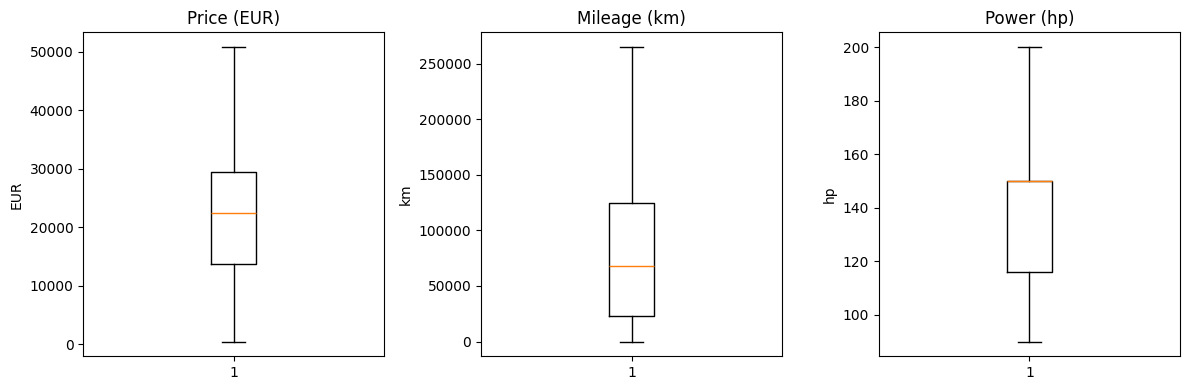

In [23]:
# Box-and-whisker plots (boxplots) to visualize outliers
# The box shows the middle 50% of the data, and dots beyond the whiskers are outliers
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].boxplot(df['price'].dropna(), vert=True)
ax[0].set_title('Price (EUR)')
ax[0].set_ylabel('EUR')

ax[1].boxplot(df['mileage'].dropna(), vert=True)
ax[1].set_title('Mileage (km)')
ax[1].set_ylabel('km')

ax[2].boxplot(df['power_hp'].dropna(), vert=True)
ax[2].set_title('Power (hp)')
ax[2].set_ylabel('hp')

plt.tight_layout()


## 8. Detecting logically inconsistent values

Some errors are not statistical outliers but logical inconsistencies.

Examples:
- Very high mileage for very recent registration dates
- Negative or zero values where not meaningful
- Incompatible combinations of variables

In this section we:
- Define simple logical sanity checks
- Identify suspicious records
- Decide how to handle them

This step increases trust in the dataset.

---


In [24]:
# Use today's date to check for impossible future dates
today = pd.Timestamp.today()

# Basic sanity checks for numeric values
df['invalid_price'] = df['price'] <= 0
df['invalid_mileage'] = df['mileage'] <= 0
df['invalid_power_hp'] = df['power_hp'] <= 0

# Registration dates should not be in the future
df['future_registration'] = df['registration_date'] > today

# Example of a suspicious combination: very new car with huge mileage
recent_year = today.year - 1
df['recent_with_high_mileage'] = (df['registration_year'] >= recent_year) & (df['mileage'] > 300000)

# Combine any logical issues into a single flag
logical_issue_cols = [
    'invalid_price',
    'invalid_mileage',
    'invalid_power_hp',
    'future_registration',
    'recent_with_high_mileage',
]
df['logical_issue'] = df[logical_issue_cols].any(axis=1)

# Count how many rows fail each rule
df[logical_issue_cols + ['logical_issue']].sum()


invalid_price                0
invalid_mileage             41
invalid_power_hp             0
future_registration          0
recent_with_high_mileage     0
logical_issue               41
dtype: int64

**Optional decision: remove logically inconsistent rows**

Run the next cell only if the class agrees these rows are errors.
If you keep them, document the potential risk for later analysis.


In [25]:
# OPTIONAL DECISION: drop rows with logical inconsistencies
# Run this cell only if the class agrees to remove these rows
df = df[~df['logical_issue']]
df.shape


(3380, 27)

## 9. Feature selection and basic feature engineering

Not all collected variables are equally useful.

In this section we:
- Remove columns that are irrelevant or redundant
- Rename columns to clear, consistent names
- Create simple derived features if appropriate

Complex transformations are intentionally avoided at this stage.

---


In [26]:
# Decide which columns to keep for the analytical dataset
columns_to_keep = [
    'make',
    'model',
    'brand',
    'price',
    'price_label',
    'mileage',
    'power_hp',
    'registration_date',
    'registration_year',
    'registration_month',
    'fuel_clean',
    'country_clean',
    'page',
    'price_outlier_iqr',
    'mileage_outlier_iqr',
    'power_outlier_iqr',
    'logical_issue',
]

# Keep only those columns (fixed schema, so all should exist)
df_final = df[columns_to_keep].copy()

# Rename columns for clarity and consistency
df_final = df_final.rename(columns={
    'price': 'price_eur',
    'mileage': 'mileage_km',
    'fuel_clean': 'fuel_type',
    'country_clean': 'listing_country',
})

# Simple feature: car age in years
df_final['age_years'] = today.year - df_final['registration_year']

df_final.head()


,make,model,brand,price_eur,price_label,mileage_km,power_hp,registration_date,registration_year,registration_month,fuel_type,listing_country,page,price_outlier_iqr,mileage_outlier_iqr,power_outlier_iqr,logical_issue,age_years
0,audi,a3,audi,690,toolow-price,234163.0,105.0,2003-06-01,2003.0,6.0,diesel,germany,1,False,False,False,False,22.0
1,audi,a3,audi,16980,good-price,76000.0,179.0,2014-12-01,2014.0,12.0,petrol,germany,1,False,False,False,False,11.0
2,audi,a3,audi,9950,top-price,174549.0,110.0,2015-04-01,2015.0,4.0,diesel,germany,1,False,False,False,False,10.0
3,audi,a3,audi,13950,top-price,91700.0,179.0,2013-12-01,2013.0,12.0,petrol,germany,1,False,False,False,False,12.0
4,audi,a3,audi,22950,top-price,36216.0,150.0,2022-12-01,2022.0,12.0,petrol,germany,1,False,False,False,False,3.0


## 10. Final validation checks

Before saving the processed dataset, we perform final checks.

These include:
- Verifying expected columns are present
- Checking value ranges
- Confirming no unintended data loss occurred

If something looks suspicious, it should be addressed now.

---


In [27]:
# Final dataset size
df_final.shape


(3380, 18)

In [28]:
# Quick overview of distributions and missing values
df_final.describe(include='all').transpose()


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
make,3380,1,audi,3380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,3380,1,a3,3380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,3380,1,audi,3380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_eur,3380.0,NaN,NaN,NaN,21395.195562,500.0,13490.0,22315.0,28990.0,50790.0,10277.800746
price_label,3380,7,fair-price,1124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage_km,3373.0,NaN,NaN,NaN,82085.619626,1.0,24350.0,69000.0,126344.0,265000.0,65841.932331
power_hp,3380.0,NaN,NaN,NaN,139.214793,90.0,116.0,150.0,150.0,200.0,22.579576
registration_date,3350,NaN,NaN,NaN,2019-02-01 13:11:21.313432832,1997-01-01 00:00:00,2015-04-01 00:00:00,2021-04-01 00:00:00,2023-12-01 00:00:00,2025-12-01 00:00:00,NaN
registration_year,3350.0,NaN,NaN,NaN,2018.619701,1997.0,2015.0,2021.0,2023.0,2025.0,6.080615
registration_month,3350.0,NaN,NaN,NaN,6.618806,1.0,3.0,7.0,10.0,12.0,3.481994


## 11. Saving the processed dataset

The cleaned dataset is saved separately from the raw data.

Best practices applied:
- Save to `data/processed/`
- Use a clear and descriptive filename
- Do not manually edit the output file

This dataset will be used in the next session for cloud storage.

---


In [29]:
# Create the processed folder if it does not exist
processed_dir = repo_root / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

# Add a timestamp so each run creates a new file
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_path = processed_dir / f'autoscout24_listings_processed_audi_a3_germany_{timestamp}.csv'

# Save without the index column
df_final.to_csv(output_path, index=False)
print('Saved to', output_path)


Saved to c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\data\processed\autoscout24_listings_processed_audi_a3_germany_20251227_234423.csv


## 12. Summary of preprocessing decisions

This final section summarizes the main decisions taken during preprocessing:
- Missing values were inspected and documented before any action
- `price` and `mileage` were converted to numeric values
- `registration` was parsed to a real date and split into year and month
- Fuel and country codes were mapped to readable labels (with room to extend)
- Exact duplicate rows may be removed if the class agrees
- Outliers were flagged using the IQR rule (removal is optional)
- Logical inconsistencies were flagged for review (removal is optional)
- A smaller set of clear, consistent columns was selected

Documenting decisions is part of professional data work.
